In [ ]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/time01.csv")
df

In [ ]:
df.info()

In [ ]:
df['time'] = pd.to_datetime(df['time'])

In [ ]:
df.dtypes

In [ ]:
df.set_index('time', inplace=True)

In [ ]:
df.index

In [ ]:
df.resample('5min')[['price', 'amount']].sum()

In [ ]:
df2 = df.resample("5min")[['price', 'amount']].agg(['sum', 'min','max'])
df2

In [ ]:
df2.info()

In [ ]:
df2.columns

In [ ]:
# 1분 간격으로 샘플링
df3 = df.resample('1min')[['price', 'amount']].last()
df3

In [ ]:
# 선형 보간법
df3.interpolate(method='linear')

---

In [1]:
import pandas as pd

df = pd.read_csv('http://114.207.245.181:13000/csv/bike.csv', 
                 names=['대여시간', '대여위치', '반납시간', '반납위치'])

df['대여시간'] = pd.to_datetime(df['대여시간'])
df['반납시간'] = pd.to_datetime(df['반납시간'])

In [2]:
df.dtypes

대여시간    datetime64[ns]
대여위치             int64
반납시간    datetime64[ns]
반납위치             int64
dtype: object

In [3]:
df['이용시간'] = df['반납시간'] - df['대여시간']
df.head(3)

,대여시간,대여위치,반납시간,반납위치,이용시간
0,2019-05-01 00:01:07,1908,2019-05-01 00:03:52,1957,0 days 00:02:45
1,2019-05-01 00:03:06,241,2019-05-01 00:04:25,255,0 days 00:01:19
2,2019-05-01 00:00:22,1224,2019-05-01 00:04:36,1249,0 days 00:04:14


In [4]:
df.dtypes

대여시간     datetime64[ns]
대여위치              int64
반납시간     datetime64[ns]
반납위치              int64
이용시간    timedelta64[ns]
dtype: object

In [5]:
df['이용시간_초단위'] = df['이용시간'].dt.total_seconds()
df['이용시간_분단위'] = df['이용시간'].dt.total_seconds() / 60
df['이용시간_시단위'] = df['이용시간'].dt.total_seconds() / 3600
df.head(3)

,대여시간,대여위치,반납시간,반납위치,이용시간,이용시간_초단위,이용시간_분단위,이용시간_시단위
0,2019-05-01 00:01:07,1908,2019-05-01 00:03:52,1957,0 days 00:02:45,165.0,2.750000,0.045833
1,2019-05-01 00:03:06,241,2019-05-01 00:04:25,255,0 days 00:01:19,79.0,1.316667,0.021944
2,2019-05-01 00:00:22,1224,2019-05-01 00:04:36,1249,0 days 00:04:14,254.0,4.233333,0.070556


In [6]:
df1 = df.set_index('대여시간')
df1

,대여위치,반납시간,반납위치,이용시간,이용시간_초단위,이용시간_분단위,이용시간_시단위
대여시간,,,,,,,
2019-05-01 00:01:07,1908,2019-05-01 00:03:52,1957,0 days 00:02:45,165.0,2.750000,0.045833
2019-05-01 00:03:06,241,2019-05-01 00:04:25,255,0 days 00:01:19,79.0,1.316667,0.021944
2019-05-01 00:00:22,1224,2019-05-01 00:04:36,1249,0 days 00:04:14,254.0,4.233333,0.070556
2019-05-01 00:01:52,521,2019-05-01 00:04:50,520,0 days 00:02:58,178.0,2.966667,0.049444
2019-05-01 00:01:11,364,2019-05-01 00:04:52,361,0 days 00:03:41,221.0,3.683333,0.061389
...,...,...,...,...,...,...,...
2019-05-31 23:25:34,2217,2019-06-01 08:49:59,2289,0 days 09:24:25,33865.0,564.416667,9.406944
2019-05-31 22:12:06,722,2019-06-01 09:37:07,1140,0 days 11:25:01,41101.0,685.016667,11.416944
2019-05-31 21:48:05,1814,2019-06-01 09:57:32,1849,0 days 12:09:27,43767.0,729.450000,12.157500


In [7]:
# weekly_borrow = df1.resample("W")[['대여위치']].count()
daily_borrow = df1.resample("D")[['대여위치']].count()
daily_borrow

,대여위치
대여시간,
2019-05-01,76052
2019-05-02,72089
2019-05-03,73345
2019-05-04,66010
2019-05-05,66549
2019-05-06,74429
2019-05-07,70187
2019-05-08,69910
2019-05-09,71081


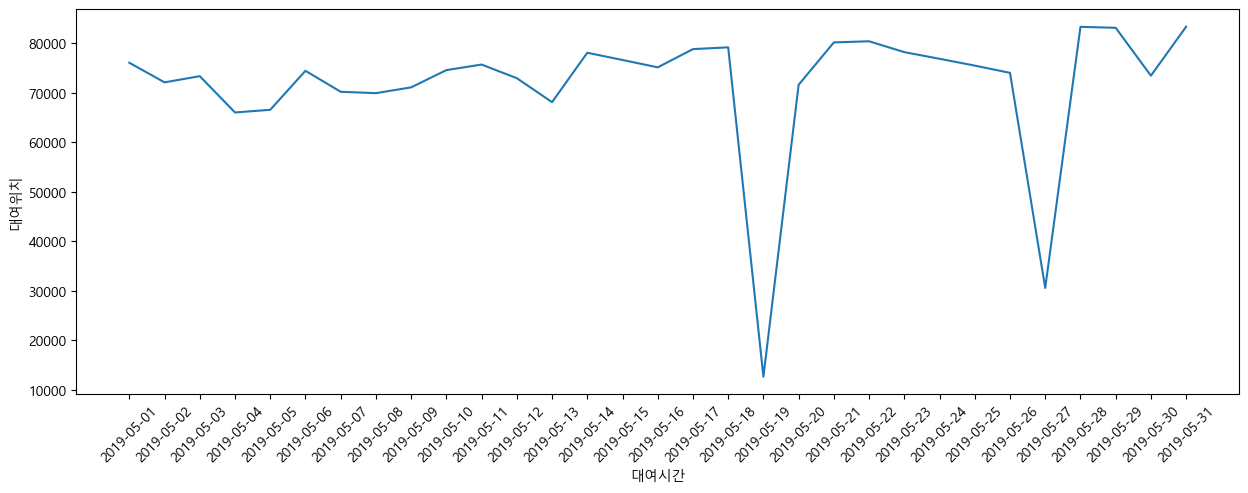

In [8]:
import seaborn_cjk
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn_cjk.patch('Gulim')
seaborn_cjk.patch()
plt.figure(figsize=(15,5))
sns.lineplot(data=daily_borrow, x=daily_borrow.index, y='대여위치')
plt.xticks(daily_borrow.index)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 인덱스에서 2079년 5월 1일 00시 01분에 대여한 건수만 필터
df3 = df1.loc['2019-05-01 00:01']
df3

In [ ]:
flow = pd.crosstab(df3['대여위치'], df3['반납위치'])
flow

In [ ]:
import seaborn_cjk
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn_cjk.patch('Gulim')
seaborn_cjk.patch()
plt.figure(figsize=(15,5))
sns.heatmap(data=flow, annot=True, mask=(flow==0))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse

# Create a sample sparse matrix (e.g., 20x20 with 10% non-zero entries)
matrix = sparse.random(20, 20, density=0.1, format='csr')

plt.figure(figsize=(6, 6))
plt.spy(matrix, markersize=5, marker='s', color='black') # 's' for square markers
plt.title("Sparsity Pattern Plot")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

---

In [ ]:
# 대여위치, 반납위치를 그룹으로 반남 횟수 구하기
df4 = df1.groupby(['대여위치', '반납위치'])[['반납위치']].count()
df4

In [ ]:
# 반납위치를 반납횟수로 컬럼 변경
df4.rename(columns={"반납위치": "반납횟수"}, inplace=True)

In [ ]:
# 인덱스초기화
df5 = df4.reset_index()
df5

In [ ]:
# 상위 25개의 반납 횟수
df4.sort_values(by='반납횟수', ascending=False)[:25]